In [33]:
# sanity checks
import sys, platform, pkgutil
import pandas as pd
print("Python:", sys.executable)
print("Version:", platform.python_version())
print("xarray installed?", pkgutil.find_loader("xarray") is not None)

Python: /Users/vb/Desktop/VBThesisCode2_FastAPI/.venv/bin/python
Version: 3.11.11
xarray installed? True


In [34]:
import xarray as xr
#  path for the NetCDF file downloaded from Davis weather station data at Green Village
nc_path = "../input/ExternalTemp/davis-TUD-GV_Green_Village_202501.nc"

ds = xr.open_dataset(nc_path)
ds  # print a summary: dimensions, coords, data_vars, attributes

<xarray.Dataset> Size: 6MB
Dimensions:                   (time: 43201)
Dimensions without coordinates: time
Data variables: (12/16)
    epoch_time                (time) int32 173kB ...
    time_as_string            (time) <U19 3MB ...
    latitude                  float32 4B ...
    longitude                 float32 4B ...
    altitude                  float32 4B ...
    pressure                  (time) float32 173kB ...
    ...                        ...
    rain_rate                 (time) float32 173kB ...
    UV_radiation              (time) float32 173kB ...
    wind_speed                (time) float32 173kB ...
    wind_to_direction         (time) float32 173kB ...
    wind_gust_speed           (time) float32 173kB ...
    wind_gust_from_direction  (time) float32 173kB ...
Attributes:
    title:         weather station data
    institution:   Delft University of Technology
    source:        surface observation
    history:       produced on 2025-03-25 by Marc Schleiss
    sensor_type:   Davis Vantage Pro2
    site_name:     Green_Village
    sensor_name:   davis-TUD-GV
    project_name:  Rotterdam Atmospheric Measurement Network (RAMN), Ruisdael...
    url:           https://ruisdael-observatory.nl/
    contributors:  Marc Schleiss, Mahaut Sourzac, Marjolein van Esch, Jelle B...
    data_license:  CC BY 4.0 https://creativecommons.org/licenses/by-sa/4.0/

In [35]:
# List variables & attributes - to find temperature name/units
print("Variables:", list(ds.data_vars))
for v in ds.data_vars:
    print(f"\n[{v}]")
    for k, val in ds[v].attrs.items():
        print(f"  {k}: {val}")

Variables: ['epoch_time', 'time_as_string', 'latitude', 'longitude', 'altitude', 'pressure', 'temperature', 'humidity', 'solar_irradiance', 'rain', 'rain_rate', 'UV_radiation', 'wind_speed', 'wind_to_direction', 'wind_gust_speed', 'wind_gust_from_direction']

[epoch_time]
  long_name: End time of observation period, in seconds since 1970-01-01 00:00:00 UTC
  units: s
  comment: The length of a measurement interval is 1 minute. Values are rounded to the nearest integer.

[time_as_string]
  long_name: End time of observation period in YYYY-MM-DD HH:MM:SS UTC
  units: 
  comment: This is the same as epoch_time but in human readable format.

[latitude]
  long_name: latitude of site
  units: degree_north

[longitude]
  long_name: longitude of site
  units: degree_east

[altitude]
  long_name: altitude of site
  units: m

[pressure]
  long_name: atmospheric pressure
  units: mbar
  comment: inside the console

[temperature]
  long_name: air temperature
  units: °C
  comment: outside, within 

In [36]:
# Convert to a tidy DataFrame and preview
df = ds.to_dataframe().reset_index()
df.head()
# df.columns

,time,epoch_time,time_as_string,latitude,longitude,altitude,pressure,temperature,humidity,solar_irradiance,rain,rain_rate,UV_radiation,wind_speed,wind_to_direction,wind_gust_speed,wind_gust_from_direction
0,0,1735689600,2025-01-01,51.996109,4.378741,2.0,1015.408508,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
1,1,1735689660,2025-01-01 00:01:00,51.996109,4.378741,2.0,1015.442383,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
2,2,1735689720,2025-01-01 00:02:00,51.996109,4.378741,2.0,1015.442383,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
3,3,1735689780,2025-01-01 00:03:00,51.996109,4.378741,2.0,1015.306885,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
4,4,1735689840,2025-01-01 00:04:00,51.996109,4.378741,2.0,1015.340759,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN


In [37]:

# non-NaN temperature values
non_nan_count = df['temperature'].notna().sum()
print(f"Non-NaN temperature values: {non_nan_count}")

# show total rows and percentage
total_rows = len(df)
percentage = (non_nan_count / total_rows) * 100
print(f"Total rows: {total_rows}, Percentage non-NaN: {percentage:.2f}%")

Non-NaN temperature values: 31204
Total rows: 43201, Percentage non-NaN: 72.23%


### Creating a new dataframe that has columns - 
1. pressure, 
2. temperature, 
3. humidity, 
4. solar_irradiance, 
5. wind_speed. 
##### For each of these columns, storing only one value per hour. 
Note - the 'time_as_string' column has 31 NaN values in 43201. Not a big problem but epoch time can be used instead (since that has no NaN values)
epoch_time values are Unix seconds (increments of 60 = 1‑minute steps), so we should convert with unit='s'

In [38]:
# CONVERTING epoch_time to datetime format
# REASON - df.resample('1h') only works if the DataFrame’s index is a DatetimeIndex — so setting it is a required step before doing time-based grouping

# --- 1) Build a UTC timestamp from epoch_time (seconds since 1970) ---
# If epoch_time ever comes as strings, this coerces to numeric first.
df["timestamp_utc"] = pd.to_datetime(pd.to_numeric(df["epoch_time"], errors="coerce"), unit="s", utc=True)

bad = df["timestamp_utc"].isna().sum()
if bad:
    print(f"Dropping {bad} rows with bad epoch_time")
clean_df = df.dropna(subset=["timestamp_utc"])

# --- 2) Index by time and sort ---
clean_df = clean_df.set_index("timestamp_utc").sort_index()

# --- 3) Choose sensor columns ---
cols = ["pressure", "temperature", "humidity", "solar_irradiance", "wind_speed"]

# Coerce selected columns to numeric (strings -> numbers; invalid -> NaN)
clean_df[cols] = clean_df[cols].apply(pd.to_numeric, errors="coerce")

# --- 4) Resample to hourly means (NaNs ignored; hour with all NaNs remains NaN) ---
clean_df_hourly = clean_df[cols].resample("1h").mean()


# Back to a regular column + add local time if useful
clean_df_hourly = clean_df_hourly.reset_index()
clean_df_hourly["time_local"] = clean_df_hourly["timestamp_utc"].dt.tz_convert("Europe/Amsterdam")

# Optional: keep only hours with a valid temperature
# df_hourly = df_hourly.dropna(subset=["temperature"])

clean_df_hourly.head()

,timestamp_utc,pressure,temperature,humidity,solar_irradiance,wind_speed,time_local
0,2025-01-01 00:00:00+00:00,1015.264587,NaN,NaN,NaN,NaN,2025-01-01 01:00:00+01:00
1,2025-01-01 01:00:00+00:00,1014.984619,NaN,NaN,NaN,NaN,2025-01-01 02:00:00+01:00
2,2025-01-01 02:00:00+00:00,1014.504272,NaN,NaN,NaN,NaN,2025-01-01 03:00:00+01:00
3,2025-01-01 03:00:00+00:00,1014.489624,NaN,NaN,NaN,NaN,2025-01-01 04:00:00+01:00
4,2025-01-01 04:00:00+00:00,1014.516235,NaN,NaN,NaN,NaN,2025-01-01 05:00:00+01:00


Note - most of the visible rows have NaN as the hourly average for sensor data (temperature, humidity, solar_irradicance and wind_speed). Looking further into this

In [ ]:
# List the sensor columns
sensor_cols = ["temperature", "humidity", "solar_irradiance", "wind_speed"] # pressure is not included as it has values even in cases when other sensor readings are NaN

# Count of rows where at least ONE sensor value is NaN
at_least_one_nan_count = clean_df_hourly[sensor_cols].isna().any(axis=1).sum()
print(f"Number of hours where at least ONE sensor value is NaN: {at_least_one_nan_count}")


# Find rows where ALL sensor values are NaN
nan_mask = clean_df_hourly[sensor_cols].isna().all(axis=1)


# Count them
nan_count = nan_mask.sum()
print(f"Number of hours with all NaN sensor values: {nan_count}")

# Create a new dataframe with only those rows
nan_rows_df = clean_df_hourly[nan_mask]

# Count of unique days in nan_rows_df
unique_days_with_all_nan = nan_rows_df["time_local"].dt.date.nunique()
print(f"Number of unique days with all NaN hours: {unique_days_with_all_nan}")

# Show the first few for inspection
print(nan_rows_df.head())

# (Optional) check percentage
total_rows = len(clean_df_hourly)
print(f"Percentage: {100 * nan_count / total_rows:.2f}%")

Number of hours where at least ONE sensor value is NaN: 192
Number of hours with all NaN sensor values: 189
Number of unique days with all NaN hours: 31
              timestamp_utc     pressure  temperature  humidity  \
0 2025-01-01 00:00:00+00:00  1015.264587          NaN       NaN   
1 2025-01-01 01:00:00+00:00  1014.984619          NaN       NaN   
2 2025-01-01 02:00:00+00:00  1014.504272          NaN       NaN   
3 2025-01-01 03:00:00+00:00  1014.489624          NaN       NaN   
4 2025-01-01 04:00:00+00:00  1014.516235          NaN       NaN   

   solar_irradiance  wind_speed                time_local  
0               NaN         NaN 2025-01-01 01:00:00+01:00  
1               NaN         NaN 2025-01-01 02:00:00+01:00  
2               NaN         NaN 2025-01-01 03:00:00+01:00  
3               NaN         NaN 2025-01-01 04:00:00+01:00  
4               NaN         NaN 2025-01-01 05:00:00+01:00  
Percentage: 25.37%


### I want to see the temporal distribution of all NaN rows

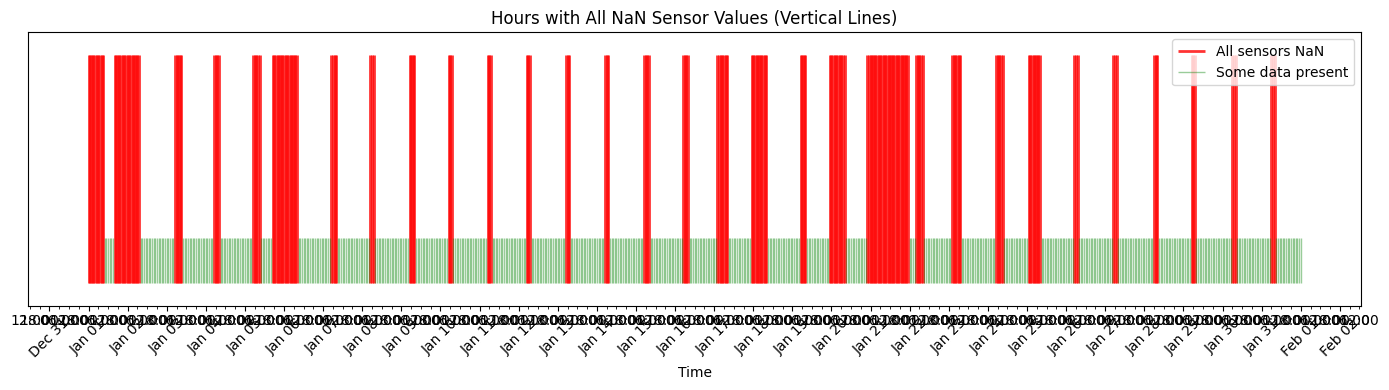

In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

nan_mask = clean_df_hourly[sensor_cols].isna().all(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))  # taller & wider

# Plot all-NaN hours as vertical lines
ax.vlines(
    clean_df_hourly.loc[nan_mask, "time_local"],
    ymin=0, ymax=1,
    color="red", alpha=0.8, linewidth=2, label="All sensors NaN"
)

# Plot hours with some data present
ax.vlines(
    clean_df_hourly.loc[~nan_mask, "time_local"],
    ymin=0, ymax=0.2,
    color="green", alpha=0.4, linewidth=1, label="Some data present"
)

# Formatting
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([])  # hide y-axis ticks
ax.set_title("Hours with All NaN Sensor Values (Vertical Lines)")
ax.set_xlabel("Time")

# Better date formatting: days as major ticks, hours as minor
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%H:%M"))

plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### When do gaps occur? — histograms
By hour‑of‑day (helps spot diurnal patterns):

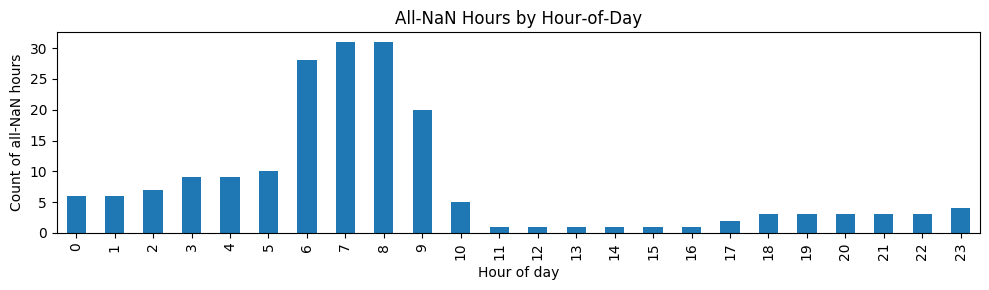

In [46]:
nan_by_hour = nan_rows_df["time_local"].dt.hour.value_counts().sort_index()
ax = nan_by_hour.plot(kind="bar", figsize=(10,3))
ax.set_title("All‑NaN Hours by Hour‑of‑Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Count of all‑NaN hours")
plt.tight_layout()
plt.show()

By day (helps see clustering by dates):

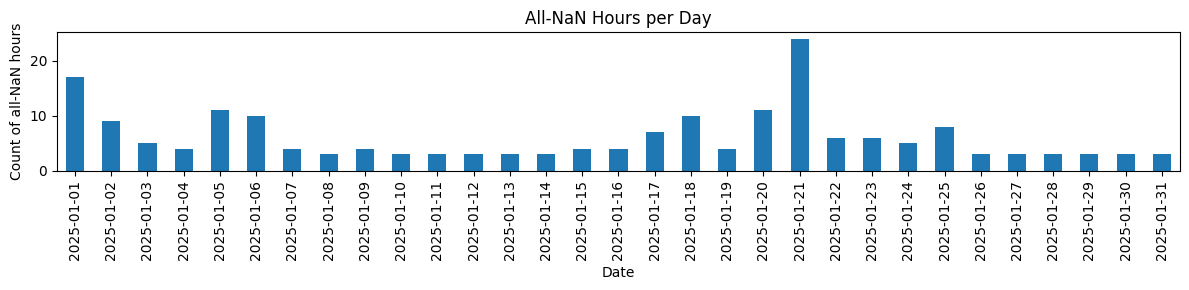

In [47]:
nan_by_day = nan_rows_df["time_local"].dt.date.value_counts().sort_index()
ax = nan_by_day.plot(kind="bar", figsize=(12,3))
ax.set_title("All‑NaN Hours per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Count of all‑NaN hours")
plt.tight_layout()
plt.show()